In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

In [65]:
import re
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from anp_emulator import Emulator
from train_anp_emulator import build_tasks, split_tasks, resolve_profile_file

In [66]:
# ── Emulator ──────────────────────────────────────────────────────────
RUN_DIR = Path('../anp_training_runs/anp_all_profiles_20260406_203048')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

if not RUN_DIR.exists():
    raise FileNotFoundError(f'Run directory not found: {RUN_DIR}')

emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)
print('Loaded:', RUN_DIR)
print('Available fields:', emu.available_fields())
assert 'Mstar' in emu.available_fields(), 'Model must include Mstar field'

Loaded: ../anp_training_runs/anp_all_profiles_20260406_203048
Available fields: ['DM_density', 'stellar_density', 'gas_density', 'temperature', 'pressure', 'metallicity', 'Mstar']


In [78]:
# ── Configuration ─────────────────────────────────────────────────────
PRED_FIELDS = ['Mstar']       # only need Mstar for predictions
N_SAMPLES   = 30

# Paths
CV_PROFILE_DIR   = Path('/mnt/home/mlee1/ceph/Profiles_cy_test/')
ONEP_PROFILE_DIR = Path('/mnt/home/mlee1/ceph/Profiles_cy_test/')
ONEP_PARAM_CSV   = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/'
                        'CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')

# args from the trained model (needed for SB test-set split)
args = SimpleNamespace(**dict(emu.args))

# Snapshot / redshift
snap_eval = int(getattr(args, 'snapnum', 90))
z_eval = float(emu.redshift_by_snap.get(snap_eval, 0.0))
print(f'Evaluating at snap={snap_eval}, z={z_eval:.3f}')

Evaluating at snap=90, z=0.000


## 1. CV set — fiducial cosmology, different random seeds

In [79]:
# Fiducial theta (from 1P_p1_0 row)
oneP_theta_df = pd.read_csv(ONEP_PARAM_CSV, sep=r'\s+', engine='python')
oneP_theta_df = oneP_theta_df.rename(columns={'#Name': 'tag'})
theta_fid = oneP_theta_df[oneP_theta_df['tag'] == '1P_p1_0'].iloc[0, 1:-1].to_numpy(dtype=np.float32)

# Discover CV files for the training snapshot
cv_pat = re.compile(r'IllustrisTNG_(CV_\d+)_snap(\d+)\.npz$')
cv_files = {}
for fp in sorted(CV_PROFILE_DIR.glob('IllustrisTNG_CV_*_snap*.npz')):
    m = cv_pat.match(fp.name)
    if m is None:
        continue
    if int(m.group(2)) == snap_eval:
        cv_files[m.group(1)] = fp

cv_true, cv_pred, cv_logM, cv_theta = [], [], [], []
for tag, fp in sorted(cv_files.items()):
    with np.load(fp) as dat:
        masses = dat['M500c'].astype(np.float32)
        r500c = dat['R500c'].astype(np.float32)
        radial_bins = dat['radial_bins'].astype(np.float32)
        true_mstar = dat['Mstar'].astype(np.float64)          # (n_halo,)

    rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], 1e-12)).astype(np.float32)

    try:
        pred = emu.predict(
            theta=theta_fid, M=masses, r_bins=rr500,
            field=PRED_FIELDS, snapnum=snap_eval,
            redshift=z_eval, n_samples=N_SAMPLES,
        )
    except TypeError:
        pred = emu.predict(
            theta=theta_fid, M=masses, r_bins=rr500,
            field=PRED_FIELDS, snapnum=snap_eval,
            n_samples=N_SAMPLES,
        )

    # Mstar prediction: mean over radial bins (constant for Mstar), convert to Msun
    pred_mstar = (10**pred.mean_log10[:, :, 0] * 1e10).mean(axis=-1)

    cv_true.append(true_mstar * 1e10)
    cv_pred.append(pred_mstar)
    cv_logM.append(np.log10(np.clip(masses, 1e-30, None)))
    cv_theta.append(np.tile(theta_fid, (len(masses), 1)))

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)
cv_logM = np.concatenate(cv_logM)
cv_theta = np.concatenate(cv_theta)

print(f'CV: {cv_true.size} halos from {len(cv_files)} simulations')

CV: 3053 halos from 27 simulations


## 2. SB35 test set — held-out LH runs

In [69]:
# Get the test-set run IDs from the train/val/test split
all_families = build_tasks(args)
_, _, test_families = split_tasks(
    all_families,
    train_frac=float(args.train_frac),
    val_frac=float(args.val_frac),
    seed=int(args.seed),
)
test_run_ids = sorted([f.run_id for f in test_families])
print(f'SB35 test runs: {len(test_run_ids)}')

# Load theta table for LH runs
theta_table = pd.read_csv(Path(args.param_csv))
param_has_run_id = 'run_id' in theta_table.columns
if param_has_run_id:
    theta_table = theta_table.set_index('run_id')

# Get parameter names from the theta table
if param_has_run_id:
    param_names = list(theta_table.columns)
else:
    param_names = list(theta_table.columns)

sb_true, sb_pred, sb_logM, sb_theta = [], [], [], []
sb_skipped = []
for run_id in test_run_ids:
    try:
        fpath = resolve_profile_file(
            run_id, base_path=Path(args.profiles_base),
            suite=args.suite, sim_set=args.sim_set, snapnum=snap_eval,
        )
    except (FileNotFoundError, OSError):
        sb_skipped.append(run_id)
        continue

    with np.load(fpath) as dat:
        masses     = dat['M500c'].astype(np.float32)
        r500c      = dat['R500c'].astype(np.float32)
        radial_bins = dat['radial_bins'].astype(np.float32)
        true_mstar = dat['Mstar'].astype(np.float64)           # (n_halo,)

    try:
        if param_has_run_id:
            theta = theta_table.loc[int(run_id)].to_numpy(dtype=np.float32)
        else:
            theta = theta_table.iloc[int(run_id)].to_numpy(dtype=np.float32)
    except (KeyError, IndexError):
        sb_skipped.append(run_id)
        continue

    rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], 1e-12)).astype(np.float32)

    try:
        pred = emu.predict(
            theta=theta, M=masses, r_bins=rr500,
            field=PRED_FIELDS, snapnum=snap_eval,
            n_samples=N_SAMPLES,
        )
    except TypeError:
        pred = emu.predict(
            theta=theta, M=masses, r_bins=rr500,
            field=PRED_FIELDS, n_samples=N_SAMPLES,
        )

    pred_mstar = (10**pred.mean_log10[:, :, 0] * 1e10).mean(axis=-1)

    sb_true.append(true_mstar * 1e10)
    sb_pred.append(pred_mstar)
    sb_logM.append(np.log10(np.clip(masses, 1e-30, None)))
    sb_theta.append(np.tile(theta, (len(masses), 1)))

sb_true = np.concatenate(sb_true)
sb_pred = np.concatenate(sb_pred)
sb_logM = np.concatenate(sb_logM)
sb_theta = np.concatenate(sb_theta)
print(f'SB35 test: {sb_true.size} halos from {len(test_run_ids) - len(sb_skipped)} runs')
if sb_skipped:
    print(f'  Skipped {len(sb_skipped)} runs due to missing files/parameters')

Built 1009 run families (1009 snapshots) from 1012 discovered runs (skipped 3).
Example family run_id=0, snapshots=1, x=(128, 30, 38), y=(128, 30, 7)
SB35 test runs: 102
SB35 test: 12574 halos from 102 runs


## 3. 1P set — one-parameter variations

In [70]:
# Load 1P parameter table
onep_params = pd.read_csv(ONEP_PARAM_CSV, sep=r'\s+', engine='python')
onep_params = onep_params.rename(columns={'#Name': 'tag'})

# Resolve theta columns (exclude tag and seed)
numeric_cols = [c for c in onep_params.columns
                if c != 'tag' and pd.api.types.is_numeric_dtype(onep_params[c])]
numeric_cols = [c for c in numeric_cols if str(c).strip().lower() != 'seed']
theta_cols = numeric_cols[:emu.theta_dim]

# Discover 1P profile files at the evaluation snapshot
onep_pat = re.compile(r'IllustrisTNG_(1P_.+)_snap(\d+)\.npz$')
onep_file_map = {}  # tag -> filepath
for fp in sorted(ONEP_PROFILE_DIR.glob('IllustrisTNG_1P_*_snap*.npz')):
    m = onep_pat.match(fp.name)
    if m is None:
        continue
    if int(m.group(2)) == snap_eval:
        onep_file_map[m.group(1)] = fp

# Keep tags present in both files and parameter table
onep_param_tags = set(onep_params['tag'].astype(str))
onep_tags = sorted(set(onep_file_map.keys()) & onep_param_tags)

op_true, op_pred, op_logM, op_theta, op_tags_used = [], [], [], [], []
op_skipped = []
for tag in onep_tags:
    row = onep_params[onep_params['tag'].astype(str) == tag]
    if len(row) == 0:
        op_skipped.append(tag)
        continue
    theta = row.iloc[0][theta_cols].to_numpy(dtype=np.float32)

    fp = onep_file_map[tag]
    with np.load(fp) as dat:
        masses     = dat['M500c'].astype(np.float32)
        r500c      = dat['R500c'].astype(np.float32)
        radial_bins = dat['radial_bins'].astype(np.float32)
        true_mstar = dat['Mstar'].astype(np.float64)

    if masses.size == 0:
        op_skipped.append(tag)
        continue

    rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], 1e-12)).astype(np.float32)

    try:
        pred = emu.predict(
            theta=theta, M=masses, r_bins=rr500,
            field=PRED_FIELDS, snapnum=snap_eval,
            n_samples=N_SAMPLES,
        )
    except TypeError:
        pred = emu.predict(
            theta=theta, M=masses, r_bins=rr500,
            field=PRED_FIELDS, n_samples=N_SAMPLES,
        )

    pred_mstar = (10**pred.mean_log10[:, :, 0] * 1e10).mean(axis=-1)

    op_true.append(true_mstar * 1e10)
    op_pred.append(pred_mstar)
    op_logM.append(np.log10(np.clip(masses, 1e-30, None)))
    op_theta.append(np.tile(theta, (len(masses), 1)))
    op_tags_used.append(tag)

op_true = np.concatenate(op_true)
op_pred = np.concatenate(op_pred)
op_logM = np.concatenate(op_logM)
op_theta = np.concatenate(op_theta)
print(f'1P: {op_true.size} halos from {len(op_tags_used)} simulations')

if op_skipped:    print(f'  Skipped {len(op_skipped)} tags')

1P: 16288 halos from 129 simulations


## Combined scatter plot: Predicted vs True $M_\star$

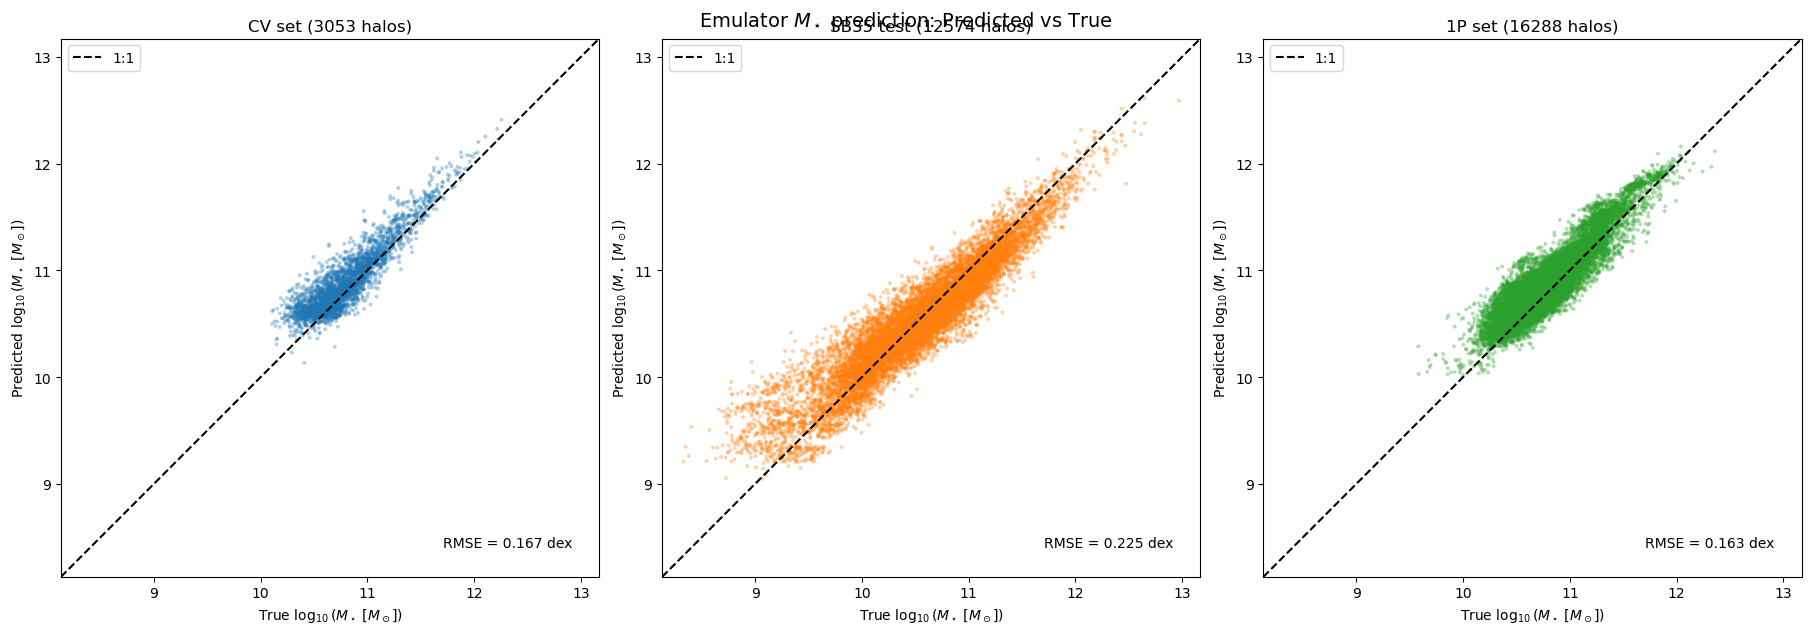

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

datasets = [
    ('CV set',      cv_true, cv_pred,  'tab:blue'),
    ('SB35 test',   sb_true, sb_pred,  'tab:orange'),
    ('1P set',      op_true, op_pred,  'tab:green'),
]

all_true = np.concatenate([cv_true, sb_true, op_true])
all_pred = np.concatenate([cv_pred, sb_pred, op_pred])
global_lo = min(np.log10(all_true[all_true > 0]).min(),
                np.log10(all_pred[all_pred > 0]).min()) - 0.2
global_hi = max(np.log10(all_true[all_true > 0]).max(),
                np.log10(all_pred[all_pred > 0]).max()) + 0.2

for ax, (label, yt, yp, color) in zip(axes, datasets):
    mask = (yt > 0) & (yp > 0)
    lt = np.log10(yt[mask])
    lp = np.log10(yp[mask])

    ax.scatter(lt, lp, s=8, alpha=0.35, color=color, edgecolors='none')
    ax.plot([global_lo, global_hi], [global_lo, global_hi],
            'k--', lw=1.5, label='1:1')

    ax.set_xlim(global_lo, global_hi)
    ax.set_ylim(global_lo, global_hi)
    ax.set_xlabel(r'True $\log_{10}(M_\star\;[M_\odot])$')
    ax.set_ylabel(r'Predicted $\log_{10}(M_\star\;[M_\odot])$')
    ax.set_title(f'{label} ({mask.sum()} halos)')
    ax.set_aspect('equal')
    ax.legend(loc='upper left')

    # RMSE in log10
    rmse = np.sqrt(np.mean((lp - lt)**2))
    ax.text(0.95, 0.05, f'RMSE = {rmse:.3f} dex',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

fig.suptitle(r'Emulator $M_\star$ prediction: Predicted vs True', fontsize=14, y=1.02)
plt.show()

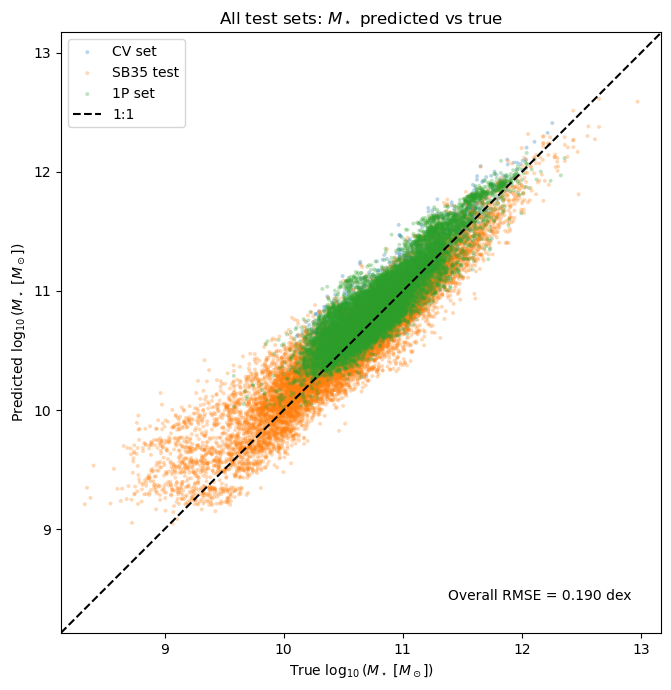

In [72]:
# Combined panel: all test sets on one plot
fig, ax = plt.subplots(figsize=(7, 7))

for label, yt, yp, color in datasets:
    mask = (yt > 0) & (yp > 0)
    ax.scatter(np.log10(yt[mask]), np.log10(yp[mask]),
              s=8, alpha=0.3, color=color, edgecolors='none', label=label)

ax.plot([global_lo, global_hi], [global_lo, global_hi],
        'k--', lw=1.5, label='1:1')

ax.set_xlim(global_lo, global_hi)
ax.set_ylim(global_lo, global_hi)
ax.set_xlabel(r'True $\log_{10}(M_\star\;[M_\odot])$')
ax.set_ylabel(r'Predicted $\log_{10}(M_\star\;[M_\odot])$')
ax.set_title(r'All test sets: $M_\star$ predicted vs true')
ax.set_aspect('equal')
ax.legend()

# Overall RMSE
all_mask = (all_true > 0) & (all_pred > 0)
rmse_all = np.sqrt(np.mean((np.log10(all_pred[all_mask]) - np.log10(all_true[all_mask]))**2))
ax.text(0.95, 0.05, f'Overall RMSE = {rmse_all:.3f} dex',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

In [73]:
from scipy.stats import spearmanr

# Pool SB35 + 1P (where theta varies); CV is constant theta so skip for correlation
pool_true  = np.concatenate([sb_true, op_true])
pool_pred  = np.concatenate([sb_pred, op_pred])
pool_theta = np.concatenate([sb_theta, op_theta])
pool_logM  = np.concatenate([sb_logM, op_logM])

# Compute residual in log10 space
pool_mask = (pool_true > 0) & (pool_pred > 0)
log_true  = np.log10(pool_true[pool_mask])
log_pred  = np.log10(pool_pred[pool_mask])
residual  = log_pred - log_true  # positive = over-prediction
theta_valid = pool_theta[pool_mask]

# Rank parameters by |Spearman correlation| with residual
corr_results = []
for i, name in enumerate(param_names):
    rho, pval = spearmanr(theta_valid[:, i], residual)
    corr_results.append({'param': name, 'spearman_rho': rho, 'abs_rho': abs(rho), 'pval': pval})

corr_df = pd.DataFrame(corr_results).sort_values('abs_rho', ascending=False).reset_index(drop=True)
print('Parameter ranking by |Spearman correlation| with Mstar residual:')
display(corr_df.head(15))

Parameter ranking by |Spearman correlation| with Mstar residual:


,param,spearman_rho,abs_rho,pval
0,UVBH0Deltaz,0.236423,0.236423,0.000000e+00
1,UVBHepDeltaz,0.221387,0.221387,0.000000e+00
2,VariableWindSpecMomentum,-0.203745,0.203745,4.561598e-268
3,MaxSfrTimescale,-0.176275,0.176275,4.030328e-200
4,Omega0,-0.165679,0.165679,1.059381e-176
5,WindEnergyIn1e51erg,0.154153,0.154153,5.813235e-153
6,MinWindVel,-0.141252,0.141252,1.654605e-128
7,QuasarThreshold,0.138597,0.138597,9.480706e-124
8,RadioFeedbackReiorientationFactor,0.123672,0.123672,9.706339e-99
9,BlackHoleFeedbackFactor,-0.108581,0.108581,2.043111e-76


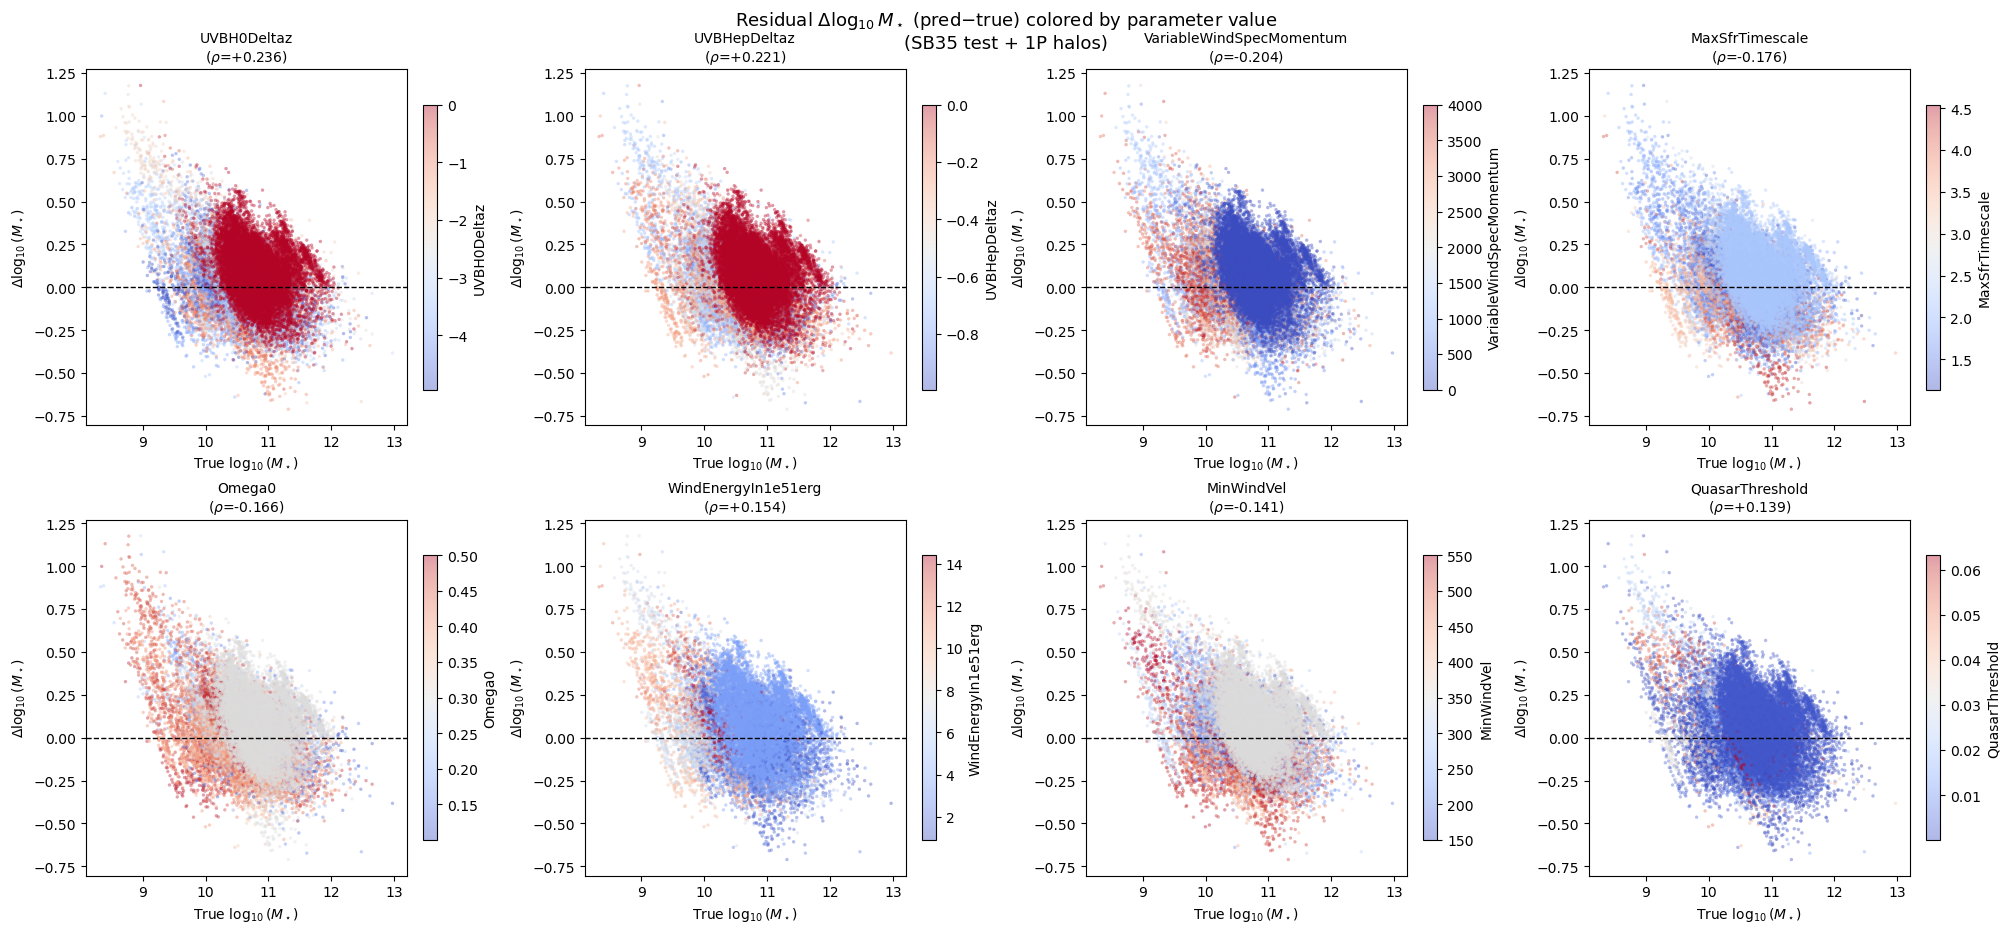

In [74]:
# Residual vs True Mstar, colored by top-8 most correlated parameters
TOP_N = 8
top_params = corr_df.head(TOP_N)

ncols = 4
nrows = (TOP_N + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                         constrained_layout=True)
axes = np.asarray(axes).ravel()

for idx in range(TOP_N):
    ax = axes[idx]
    pname = top_params.iloc[idx]['param']
    rho   = top_params.iloc[idx]['spearman_rho']
    pi    = param_names.index(pname)

    sc = ax.scatter(log_true, residual, c=theta_valid[:, pi],
                    s=6, alpha=0.4, cmap='coolwarm', edgecolors='none')
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_xlabel(r'True $\log_{10}(M_\star)$')
    ax.set_ylabel(r'$\Delta\log_{10}(M_\star)$')
    ax.set_title(f'{pname}\n($\\rho$={rho:+.3f})', fontsize=10)
    plt.colorbar(sc, ax=ax, label=pname, shrink=0.8)

for ax in axes[TOP_N:]:
    ax.set_visible(False)

fig.suptitle(r'Residual $\Delta\log_{10} M_\star$ (pred$-$true) colored by parameter value'
             '\n(SB35 test + 1P halos)', fontsize=13, y=1.02)
plt.show()

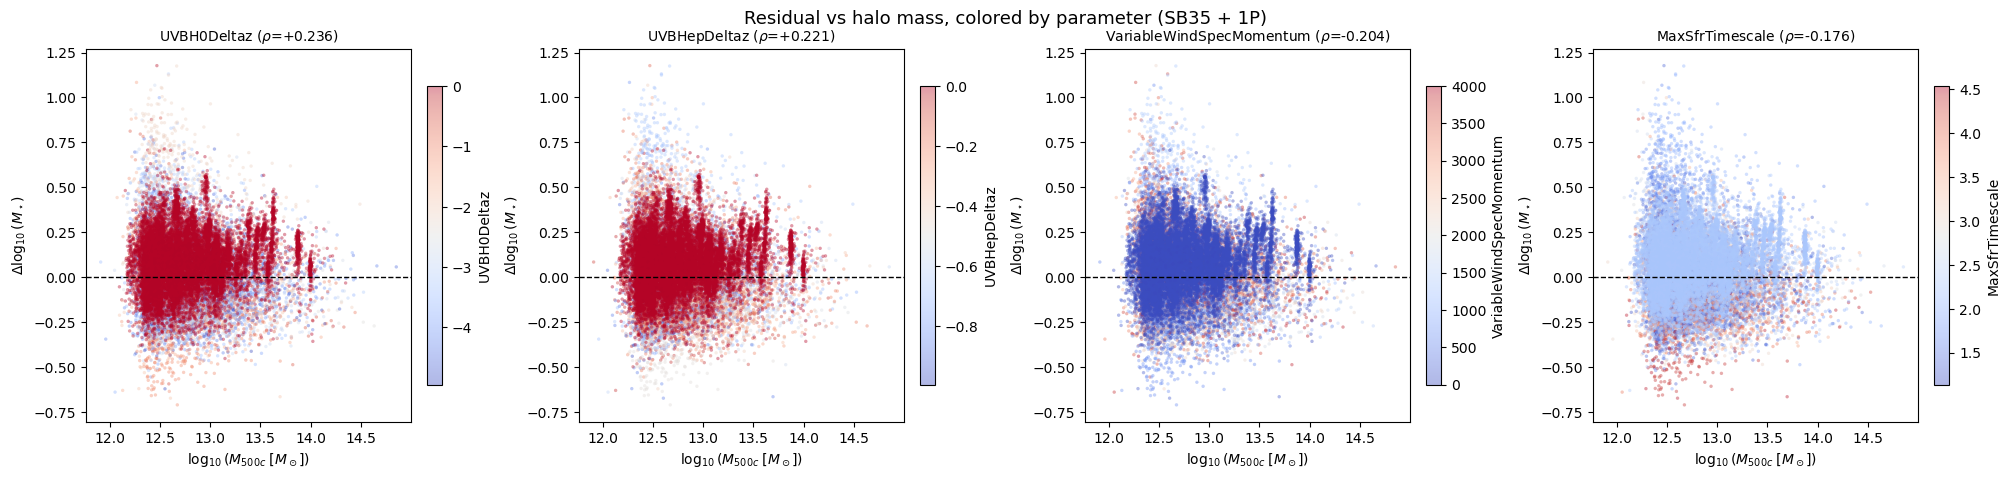

In [75]:
# Residual vs halo mass (log10 M500c), colored by top-4 parameters
TOP_M = 4
fig, axes = plt.subplots(1, TOP_M, figsize=(5 * TOP_M, 4.5), constrained_layout=True)
logM_valid = pool_logM[pool_mask]

for idx in range(TOP_M):
    ax = axes[idx]
    pname = corr_df.iloc[idx]['param']
    rho   = corr_df.iloc[idx]['spearman_rho']
    pi    = param_names.index(pname)

    sc = ax.scatter(logM_valid, residual, c=theta_valid[:, pi],
                    s=6, alpha=0.4, cmap='coolwarm', edgecolors='none')
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_xlabel(r'$\log_{10}(M_{500c}\;[M_\odot])$')
    ax.set_ylabel(r'$\Delta\log_{10}(M_\star)$')
    ax.set_title(f'{pname} ($\\rho$={rho:+.3f})', fontsize=10)
    plt.colorbar(sc, ax=ax, label=pname, shrink=0.8)

fig.suptitle(r'Residual vs halo mass, colored by parameter (SB35 + 1P)', fontsize=13, y=1.03)
plt.show()

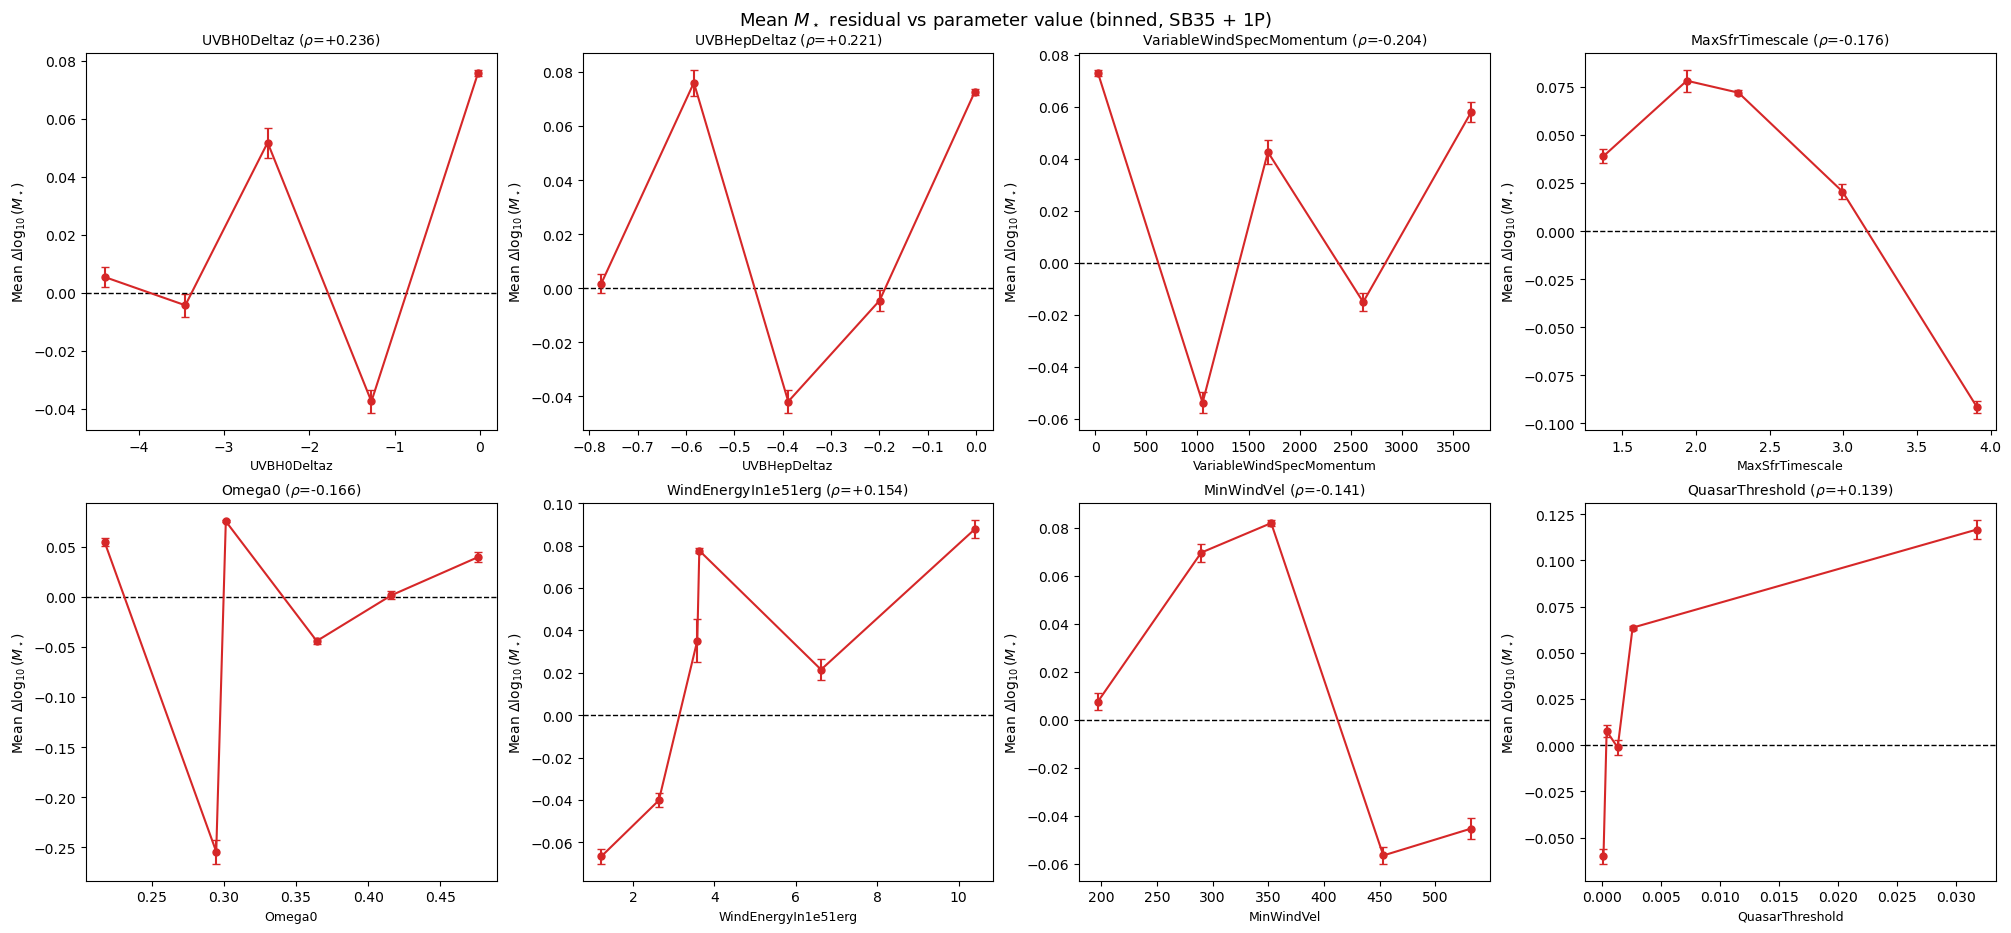

In [76]:
# Per-parameter: mean residual binned by parameter value (top-8)
fig, axes = plt.subplots(2, 4, figsize=(20, 9), constrained_layout=True)
axes = np.asarray(axes).ravel()

for idx in range(TOP_N):
    ax = axes[idx]
    pname = corr_df.iloc[idx]['param']
    rho   = corr_df.iloc[idx]['spearman_rho']
    pi    = param_names.index(pname)

    pvals = theta_valid[:, pi]
    # Bin into quantiles
    n_bins = min(10, len(np.unique(pvals)))
    try:
        bin_edges = np.quantile(pvals, np.linspace(0, 1, n_bins + 1))
        bin_edges = np.unique(bin_edges)
        bin_idx = np.digitize(pvals, bin_edges[1:-1])
    except Exception:
        ax.text(0.5, 0.5, 'Not enough variation', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(pname)
        continue

    bin_centers, bin_means, bin_stds = [], [], []
    for b in range(len(bin_edges) - 1):
        mask_b = bin_idx == b
        if mask_b.sum() < 3:
            continue
        bin_centers.append(pvals[mask_b].mean())
        bin_means.append(residual[mask_b].mean())
        bin_stds.append(residual[mask_b].std() / np.sqrt(mask_b.sum()))

    ax.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', capsize=3,
                color='tab:red', markersize=5, lw=1.5)
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_xlabel(pname, fontsize=9)
    ax.set_ylabel(r'Mean $\Delta\log_{10}(M_\star)$')
    ax.set_title(f'{pname} ($\\rho$={rho:+.3f})', fontsize=10)

for ax in axes[TOP_N:]:
    ax.set_visible(False)

fig.suptitle(r'Mean $M_\star$ residual vs parameter value (binned, SB35 + 1P)',
             fontsize=13, y=1.02)
plt.show()

In [61]:
# Build per-tag Mstar cache from the 1P data already loaded in cell 10.
# We need: for each 1P tag, the median true and predicted Mstar across halos.
import re

# Rebuild a per-tag cache of true/pred Mstar arrays (already computed above,
# but we need per-tag access rather than the flat concatenated arrays).
onep_mstar_cache = {}  # tag -> {'true': array, 'pred': array, 'logM': array, 'theta': array}
for tag in onep_tags:
    row = onep_params[onep_params['tag'].astype(str) == tag]
    if len(row) == 0:
        continue
    theta = row.iloc[0][theta_cols].to_numpy(dtype=np.float32)

    fp = onep_file_map.get(tag)
    if fp is None:
        continue

    with np.load(fp) as dat:
        masses     = dat['M500c'].astype(np.float32)
        r500c      = dat['R500c'].astype(np.float32)
        radial_bins = dat['radial_bins'].astype(np.float32)
        true_mstar = dat['Mstar'].astype(np.float64)

    if masses.size == 0:
        continue

    rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], 1e-12)).astype(np.float32)

    try:
        pred = emu.predict(
            theta=theta, M=masses, r_bins=rr500,
            field=PRED_FIELDS, snapnum=snap_eval,
            n_samples=N_SAMPLES,
        )
    except TypeError:
        pred = emu.predict(
            theta=theta, M=masses, r_bins=rr500,
            field=PRED_FIELDS, n_samples=N_SAMPLES,
        )

    pred_mstar = (10**pred.mean_log10[:, :, 0] * 1e10).mean(axis=-1)

    onep_mstar_cache[tag] = {
        'true_mstar': true_mstar * 1e10,        # Msun
        'pred_mstar': pred_mstar,                # Msun
        'M500c': masses.astype(np.float64),
        'logM': np.log10(np.clip(masses, 1e-30, None)),
        'theta': theta,
    }

print(f'Built Mstar cache for {len(onep_mstar_cache)} 1P tags')

Built Mstar cache for 129 1P tags


Found 32 base parameters


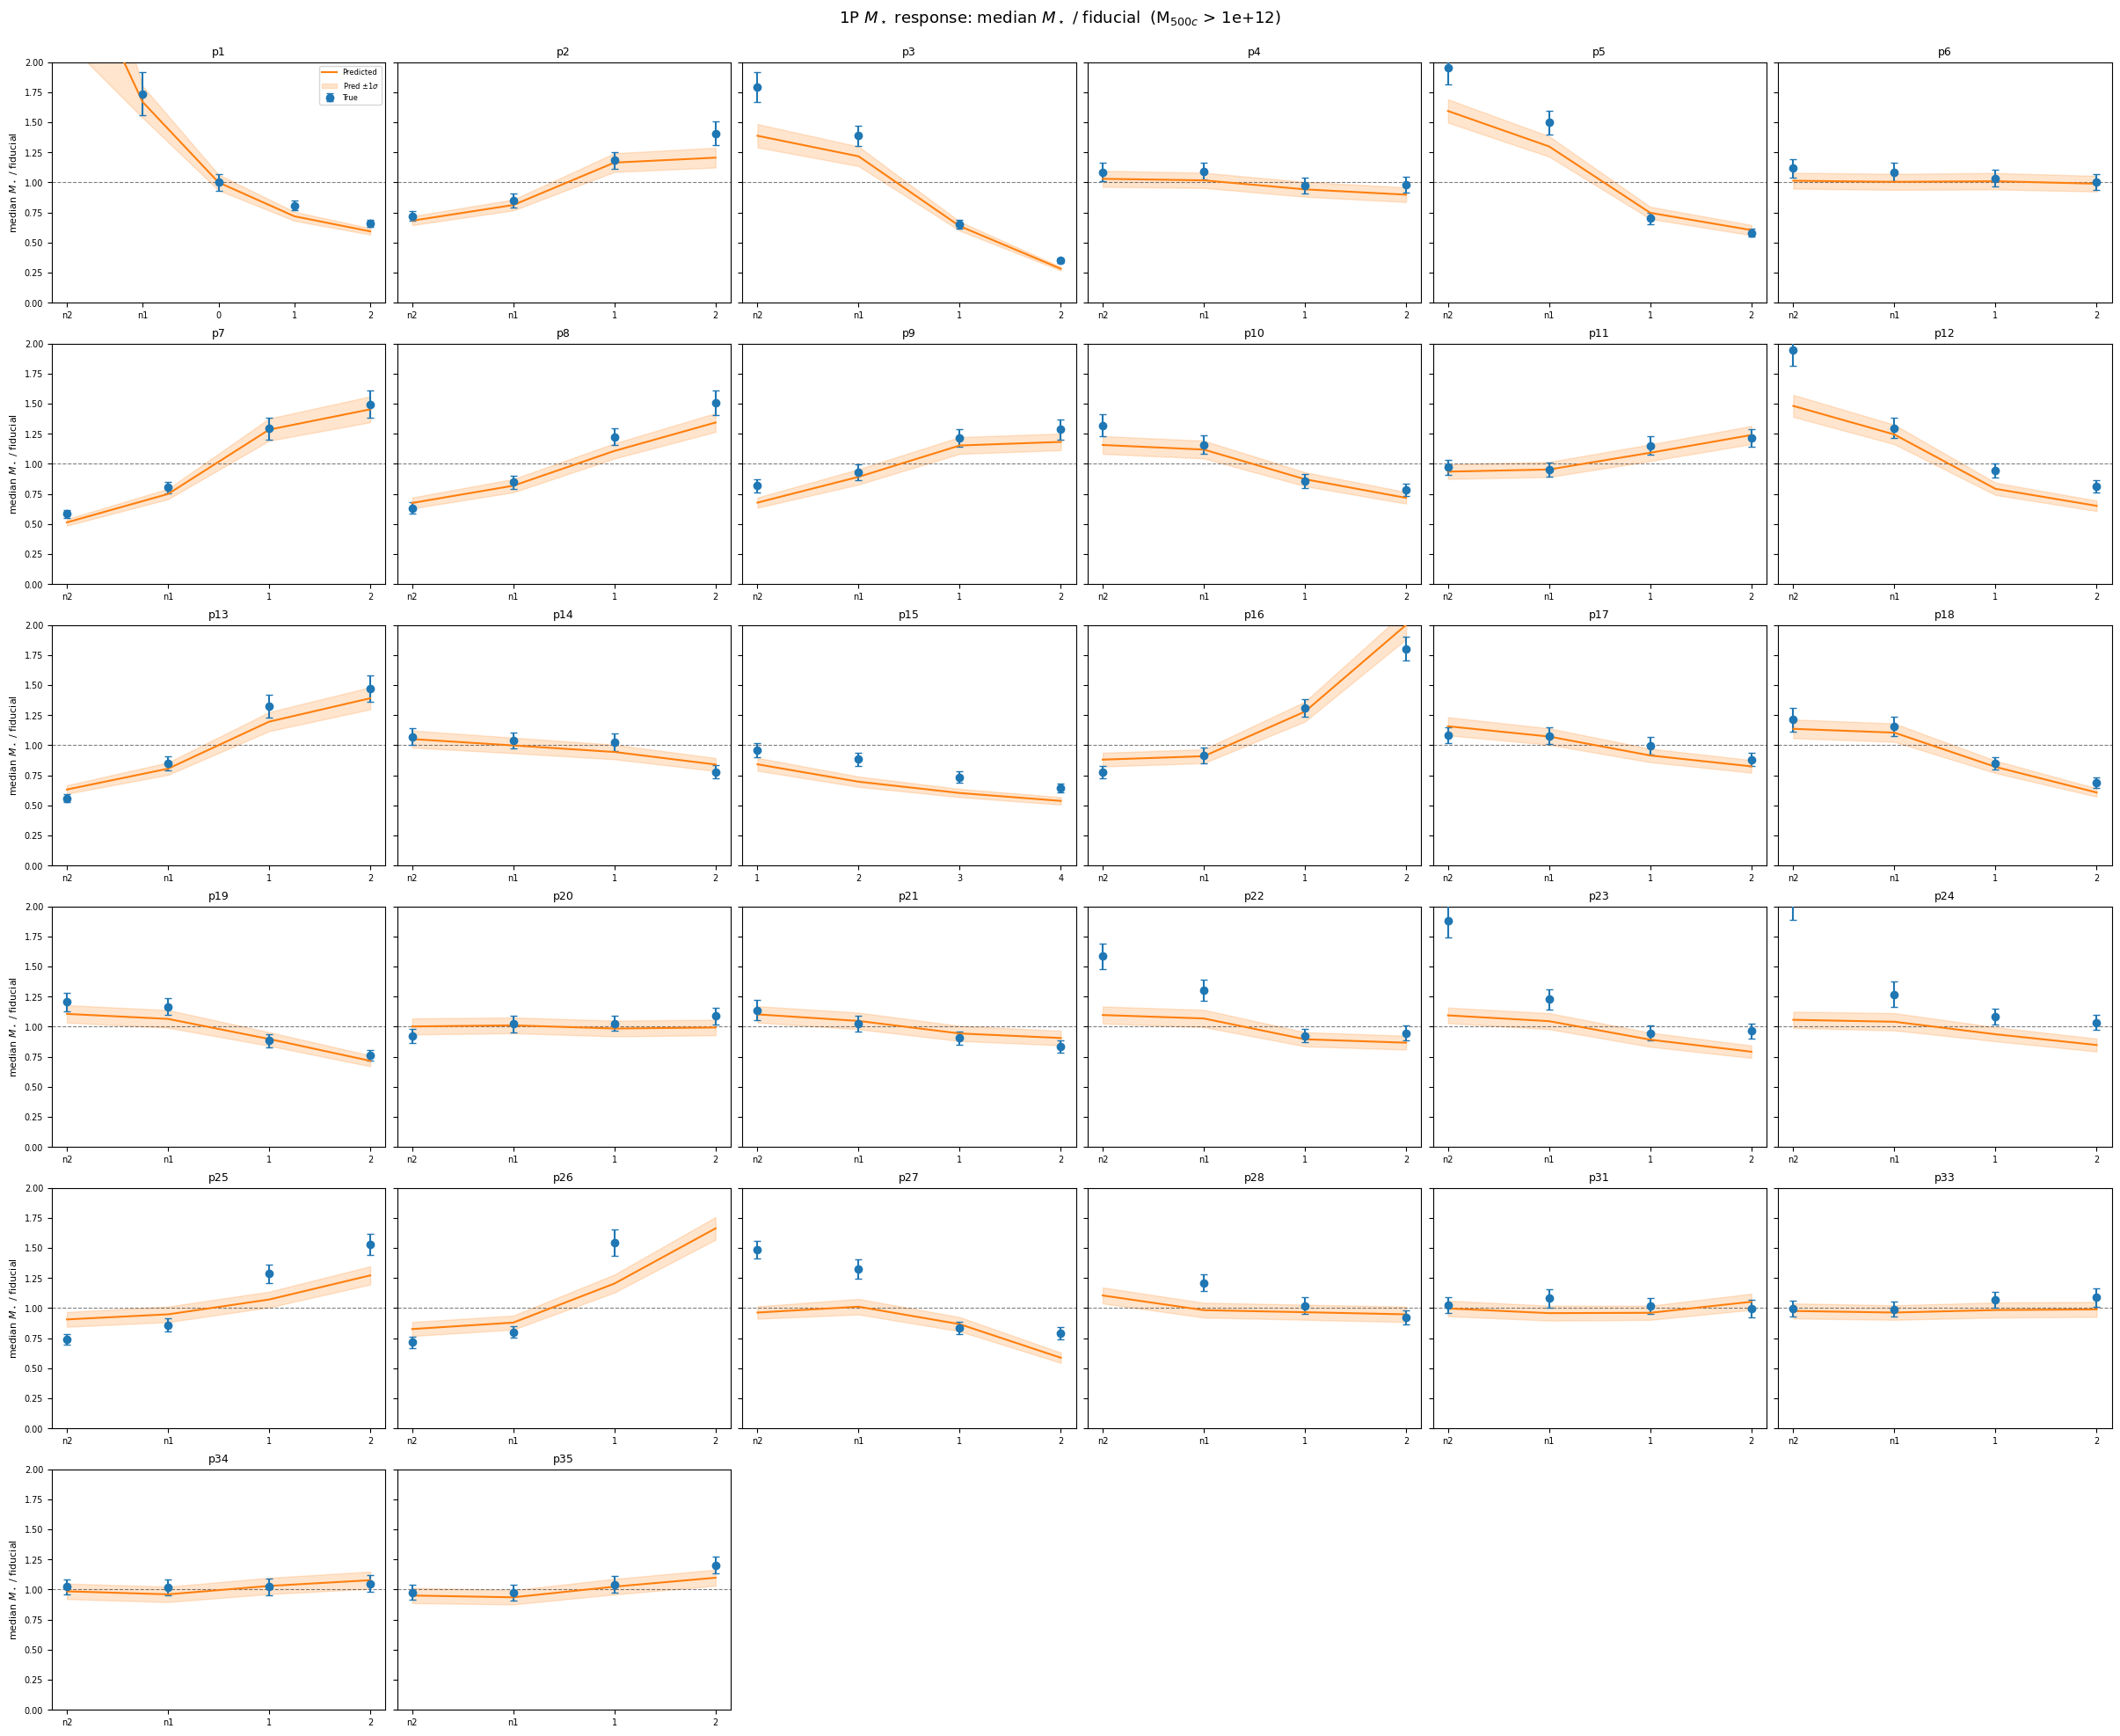

In [88]:
# 1P Family grid: median Mstar ratio (variation / fiducial) for each parameter.
# X-axis = variation level, Y-axis = median Mstar / fiducial median Mstar.
# Both true and predicted show MAD-based standard error of the median.

def _natural_sort_key(s):
    m = re.fullmatch(r'p(\d+)', str(s))
    return (0, int(m.group(1))) if m else (1, str(s))

def _suffix_sort_key(s):
    """Sort 1P suffixes: n2→-2, n1→-1, 0→0, 1→1, 2→2, 3→3, …"""
    if s.startswith('n'):
        return -int(s[1:])
    return int(s)

def _median_sigma(arr):
    """Standard error of the median via MAD."""
    med = np.median(arr)
    mad = np.median(np.abs(arr - med))
    return 1.4826 * mad * 1.2533 / np.sqrt(len(arr))

# Discover base parameters and their suffixes dynamically
tag_pat = re.compile(r'^1P_(p\d+)_(.+)$')
param_suffixes = {}  # base_param -> set of suffixes
for tag in onep_mstar_cache:
    m = tag_pat.match(tag)
    if m:
        param_suffixes.setdefault(m.group(1), set()).add(m.group(2))

base_params = sorted(param_suffixes.keys(), key=_natural_sort_key)
n_params = len(base_params)
print(f'Found {n_params} base parameters')

MASS_CUT = 1e12  # only use halos above this M500c

# ── Plot ──
ncols = 6
nrows = int(np.ceil(n_params / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows),
                         constrained_layout=True, sharey=True)
axes = np.atleast_2d(axes).ravel()

for i, base in enumerate(base_params):
    ax = axes[i]
    suffixes = sorted(param_suffixes[base], key=_suffix_sort_key)
    x_positions = np.arange(len(suffixes))

    # Per-family fiducial: the '0' suffix
    fid_tag_fam = f'1P_p1_0'
    fid_rec_fam = onep_mstar_cache.get(fid_tag_fam)
    if fid_rec_fam is None:
        ax.text(0.5, 0.5, 'No fiducial', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        ax.set_title(base, fontsize=9)
        continue

    fid_mask = fid_rec_fam['M500c'] >= MASS_CUT
    if fid_mask.sum() < 2:
        ax.set_title(base, fontsize=9)
        continue
    fid_true_median = np.median(fid_rec_fam['true_mstar'][fid_mask])
    fid_pred_median = np.median(fid_rec_fam['pred_mstar'][fid_mask])

    true_ratios, pred_ratios = [], []
    true_errs, pred_errs = [], []

    for sfx in suffixes:
        tag = f'1P_{base}_{sfx}'
        rec = onep_mstar_cache.get(tag)
        if rec is None:
            true_ratios.append(np.nan); pred_ratios.append(np.nan)
            true_errs.append(np.nan);   pred_errs.append(np.nan)
            continue

        mask = rec['M500c'] >= MASS_CUT
        if mask.sum() < 2:
            true_ratios.append(np.nan); pred_ratios.append(np.nan)
            true_errs.append(np.nan);   pred_errs.append(np.nan)
            continue

        t_med = np.median(rec['true_mstar'][mask])
        p_med = np.median(rec['pred_mstar'][mask])

        t_sigma = _median_sigma(rec['true_mstar'][mask])
        p_sigma = _median_sigma(rec['pred_mstar'][mask])

        true_ratios.append(t_med / fid_true_median)
        pred_ratios.append(p_med / fid_pred_median)
        true_errs.append(t_sigma / fid_true_median)
        pred_errs.append(p_sigma / fid_pred_median)

    true_ratios = np.array(true_ratios)
    pred_ratios = np.array(pred_ratios)
    true_errs   = np.array(true_errs)
    pred_errs   = np.array(pred_errs)

    valid = np.isfinite(true_ratios) & np.isfinite(pred_ratios)

    ax.errorbar(x_positions[valid], true_ratios[valid], yerr=true_errs[valid],
                fmt='o', ms=6, capsize=3, color='tab:blue', label='True', zorder=3)

    # Predicted: line with shaded ±1σ band on the median
    ax.plot(x_positions[valid], pred_ratios[valid],
            '-', ms=6, color='tab:orange', lw=1.5, label='Predicted', zorder=3)
    ax.fill_between(x_positions[valid],
                    pred_ratios[valid] - pred_errs[valid],
                    pred_ratios[valid] + pred_errs[valid],
                    color='tab:orange', alpha=0.2, label=r'Pred $\pm 1\sigma$', zorder=2)

    ax.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(suffixes, fontsize=7)
    ax.set_title(base, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_ylim(0, 2)

    if i % ncols == 0:
        ax.set_ylabel(r'median $M_\star$ / fiducial', fontsize=8)
    if i == 0:
        ax.legend(fontsize=6, loc='best')

for j in range(n_params, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r'1P $M_\star$ response: median $M_\star$ / fiducial  (M$_{500c}$ > '
             f'{MASS_CUT:.0e})', fontsize=13, y=1.02)
plt.show()

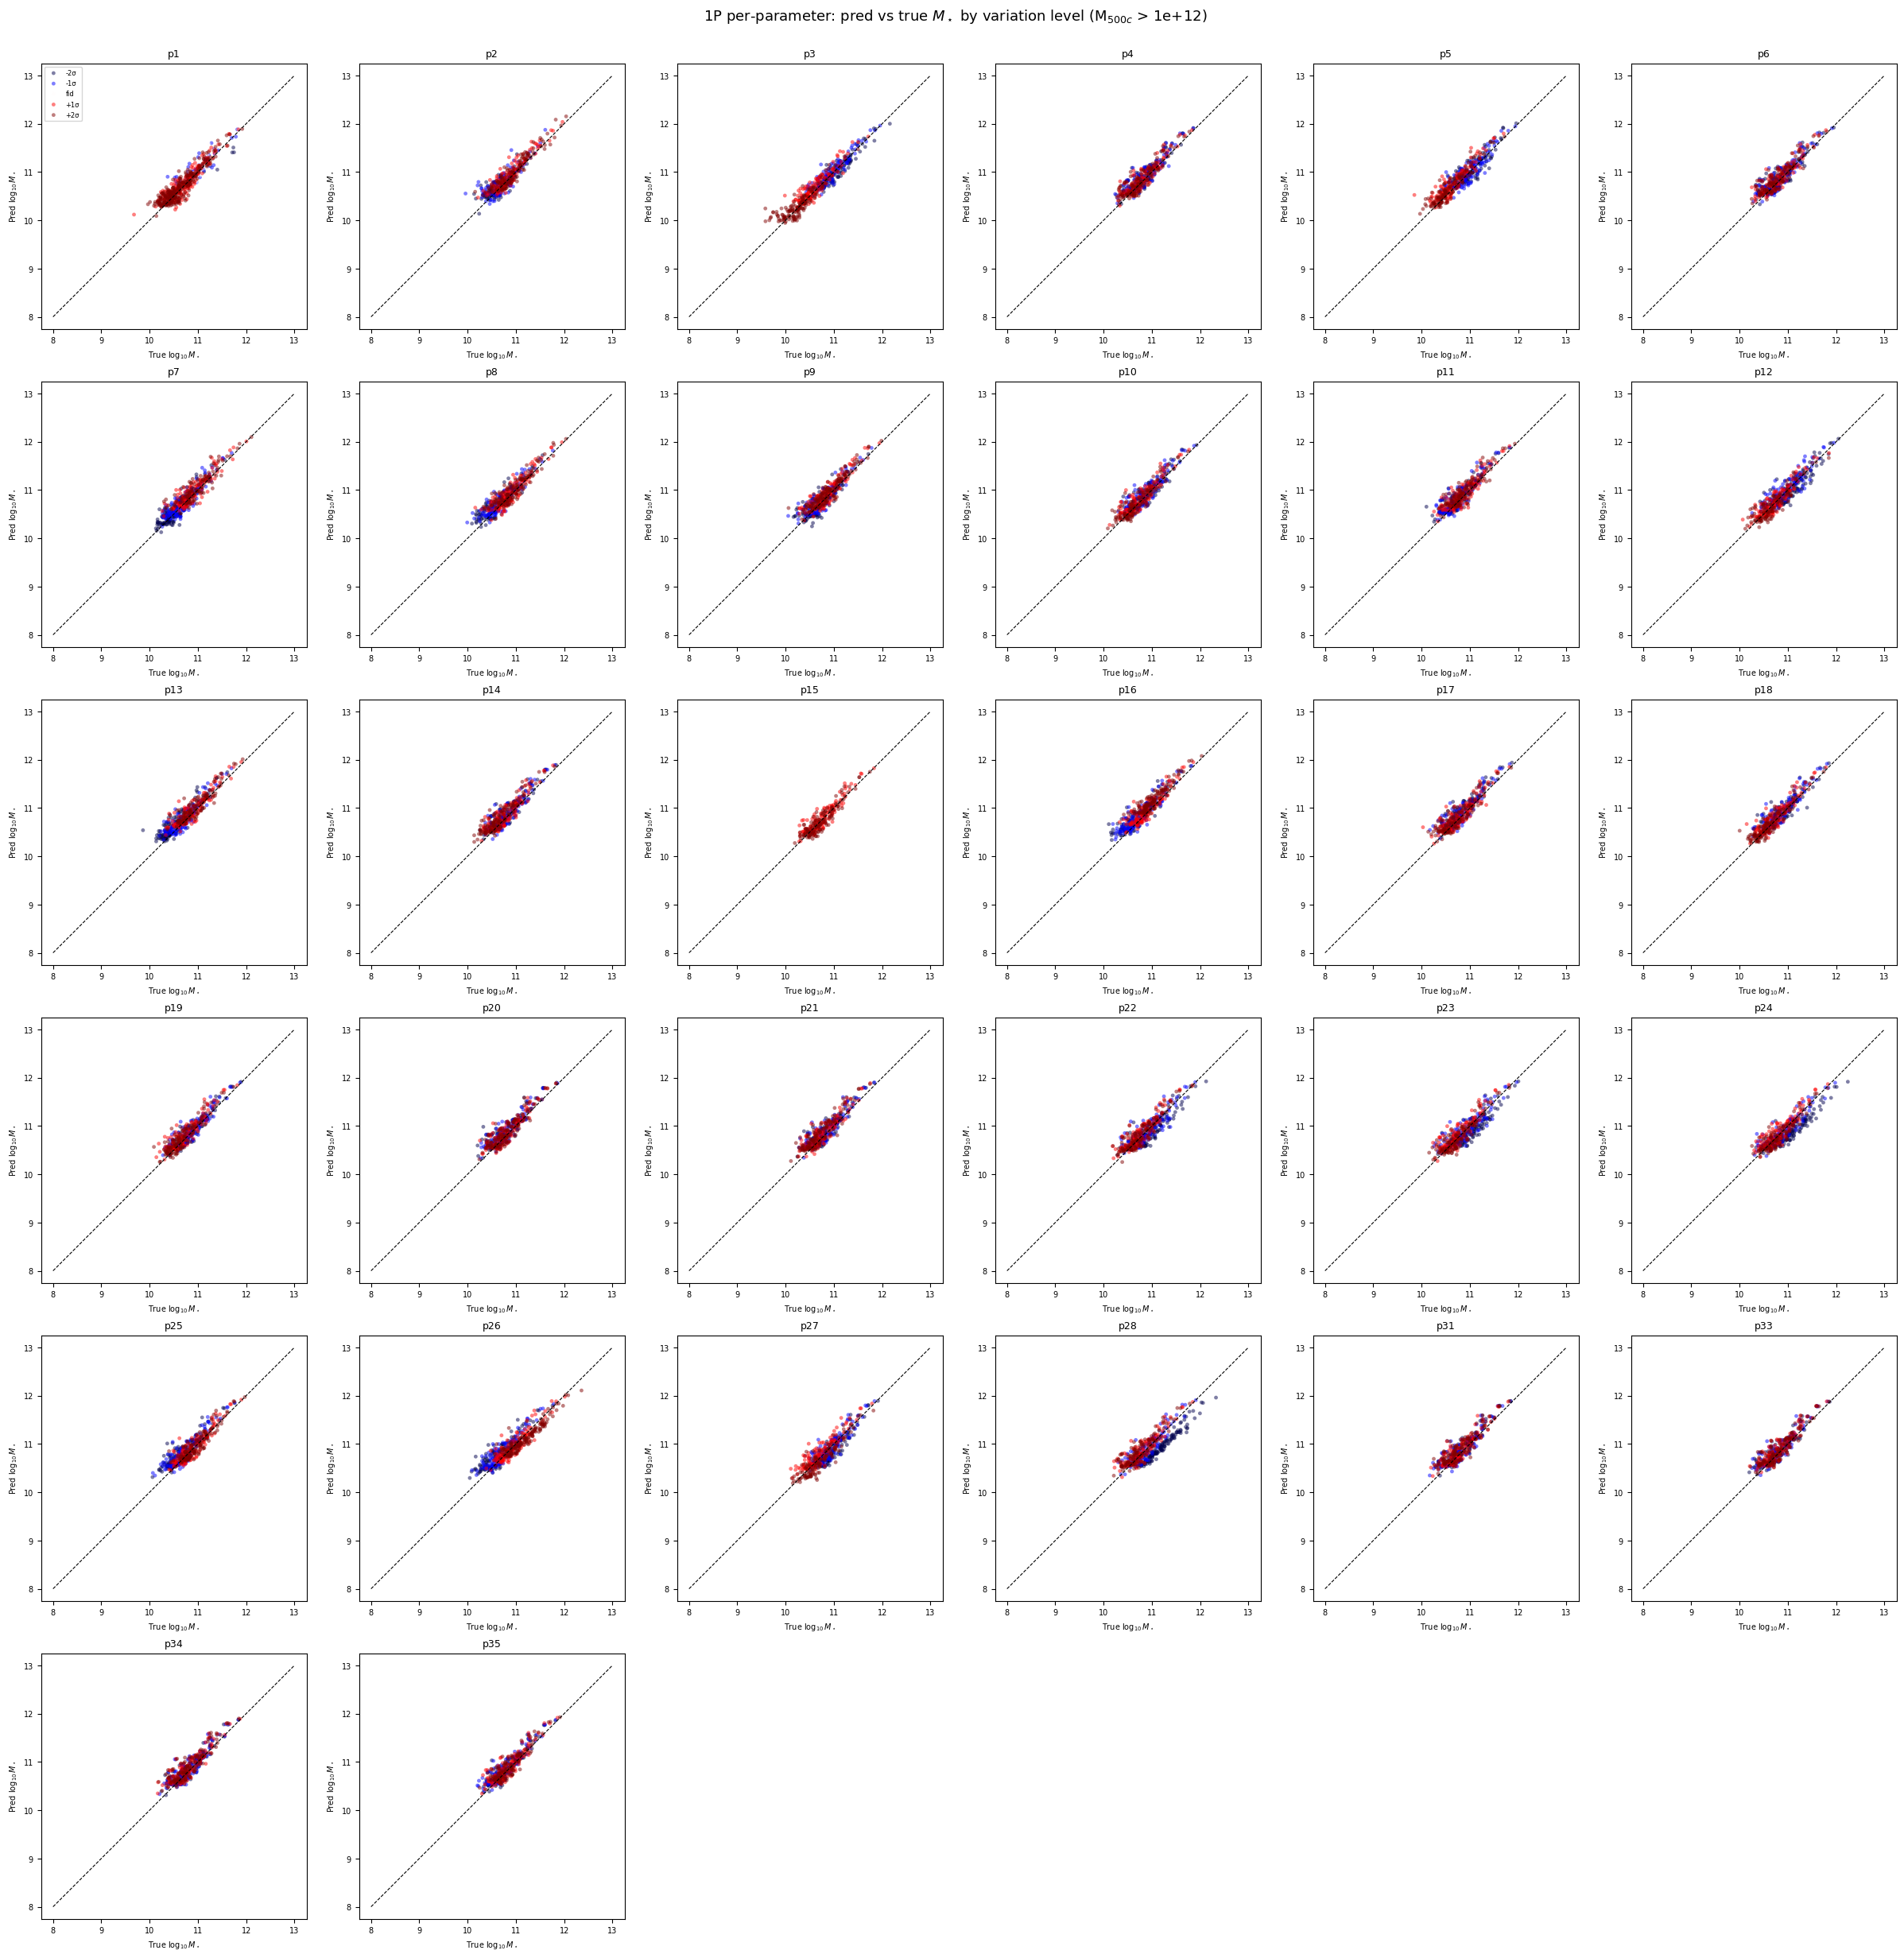

In [64]:
# Per-parameter scatter: pred vs true Mstar for each variation, overlaid.
# One panel per parameter, halos colored by variation level.

ncols = 6
nrows = int(np.ceil(n_params / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows),
                         constrained_layout=True)
axes = np.atleast_2d(axes).ravel()

var_colors = plt.cm.seismic(np.linspace(0, 1, len(variation_suffixes)))

for i, base in enumerate(base_params):
    ax = axes[i]
    for sfx, vlab, vcol in zip(variation_suffixes, variation_labels, var_colors):
        tag = f'1P_{base}_{sfx}'
        rec = onep_mstar_cache.get(tag)
        if rec is None:
            continue
        mask = (rec['true_mstar'] > 0) & (rec['pred_mstar'] > 0) & (rec['M500c'] >= MASS_CUT)
        if mask.sum() == 0:
            continue
        lt = np.log10(rec['true_mstar'][mask])
        lp = np.log10(rec['pred_mstar'][mask])
        ax.scatter(lt, lp, s=12, alpha=0.5, color=vcol, edgecolors='none', label=vlab)

    # 1:1 line
    ax.plot([8, 13], [8, 13], 'k--', lw=0.8)
    ax.set_xlabel(r'True $\log_{10} M_\star$', fontsize=7)
    ax.set_ylabel(r'Pred $\log_{10} M_\star$', fontsize=7)
    ax.set_title(base, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_aspect('equal')
    if i == 0:
        ax.legend(fontsize=6, loc='upper left', ncol=1)

for j in range(n_params, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r'1P per-parameter: pred vs true $M_\star$ by variation level'
             f' (M$_{{500c}}$ > {MASS_CUT:.0e})', fontsize=13, y=1.02)
plt.show()